In [ ]:
import pandas as pd
import re
import random
import numpy as np
import torch
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from datasets import Dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    DataCollatorWithPadding,
    Trainer, 
    TrainingArguments
)

# Load data
df = pd.read_csv("../data/scidcc/SciDCC.csv")

seed = 16
random.seed(seed)
np.random.seed(seed)

class TextCleaner():
    def __init__(self):
        pass
    
    def clean_text(self, text):
        if not isinstance(text, str):
            return ""
        text = text.lower()
        text = re.sub(r'<.*?>', '', text)
        text = re.sub(r'http\S+', '', text)
        text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
        text = re.sub(r"\s+", " ", text).strip()
        return text

cleaner = TextCleaner()
df['cleaned_text'] = df['Body'].apply(cleaner.clean_text)

label_encoder = preprocessing.LabelEncoder()
df['labels'] = label_encoder.fit_transform(df['Category'])

# Check for minimum samples per class for stratification
min_class_count = df['labels'].value_counts().min()

# non-stratified split if classes are too small
if min_class_count < 2:
    train_df, temp_df = train_test_split(
        df,
        test_size=0.2,
        random_state=seed
    )
else:
    train_df, temp_df = train_test_split(
        df,
        test_size=0.2,
        random_state=seed,
        stratify=df["labels"]
    )

# Check temp_df for stratification
temp_min_class_count = temp_df['labels'].value_counts().min()
if temp_min_class_count < 2:
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.5,
        random_state=seed
    )
else:
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.5,
        random_state=seed,
        stratify=temp_df["labels"]
    )

tokenizer = AutoTokenizer.from_pretrained("distilroberta-base")

def tokenize_data(examples):
    return tokenizer(examples["cleaned_text"], truncation=True, padding=False)

# Convert to datasets and tokenise
train_dataset = Dataset.from_pandas(train_df[['cleaned_text', 'labels']].reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df[['cleaned_text', 'labels']].reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df[['cleaned_text', 'labels']].reset_index(drop=True))

# Apply tokenisation
train_dataset = train_dataset.map(tokenize_data, batched=True)
val_dataset = val_dataset.map(tokenize_data, batched=True)
test_dataset = test_dataset.map(tokenize_data, batched=True)

# Keep only necessary columns
cols_to_keep = ["input_ids", "attention_mask", "labels"]
train_dataset = train_dataset.remove_columns([c for c in train_dataset.column_names if c not in cols_to_keep])
val_dataset = val_dataset.remove_columns([c for c in val_dataset.column_names if c not in cols_to_keep])
test_dataset = test_dataset.remove_columns([c for c in test_dataset.column_names if c not in cols_to_keep])

# Set dataset format
train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
val_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

# Load model
model = AutoModelForSequenceClassification.from_pretrained(
    "distilroberta-base",
    num_labels=len(label_encoder.classes_),
    ignore_mismatched_sizes=True  # for potential size mismatches
)

# Data collator for padding sequences
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "f1": f1_score(labels, preds, average="macro")
    }

# Training arguments
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=5e-5,
    warmup_ratio=0.1,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    fp16=torch.cuda.is_available(),
    num_train_epochs=10,
    weight_decay=0.01,
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    seed=seed,
    data_seed=seed,
    report_to="none"
)

# Trainer object for training the model
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# Train the model
trainer.train()

# Save the trained model
trainer.save_model('model')
tokenizer.save_pretrained('model')  # Also save the tokenizer

# Evaluate on test set
test_results = trainer.predict(test_dataset)
test_preds = np.argmax(test_results.predictions, axis=-1)
test_f1 = f1_score(test_results.label_ids, test_preds, average="macro")

print("Test Macro F1:", test_f1)

# Classification report
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(test_results.label_ids, test_preds, target_names=label_encoder.classes_))

Map:   0%|          | 0/9231 [00:00<?, ? examples/s]

Map:   0%|          | 0/1154 [00:00<?, ? examples/s]

Map:   0%|          | 0/1154 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_2572561/1796347065.py:156: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
Detected kernel version 5.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.
/raid/yanitsa/.cache/virtualenvs/thesis-proj-qjo_jmp_-py3.10/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and retur

Epoch,Training Loss,Validation Loss,F1
1,2.483500,1.522645,0.327794
2,1.260600,1.146268,0.477281
3,1.036400,1.099860,0.497549
4,0.932700,1.103735,0.495185
5,0.827500,1.116356,0.513555
6,0.739600,1.131138,0.505600
7,0.647300,1.107987,0.511073
8,0.576000,1.151651,0.514084
9,0.524500,1.182588,0.521293
10,0.485600,1.188169,0.514907


/raid/yanitsa/.cache/virtualenvs/thesis-proj-qjo_jmp_-py3.10/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/raid/yanitsa/.cache/virtualenvs/thesis-proj-qjo_jmp_-py3.10/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/raid/yanitsa/.cache/virtualenvs/thesis-proj-qjo_jmp_-py3.10/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/raid/yanitsa/.cache/virtualenvs/thesis-proj-qjo_jmp_-py3.10/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 

Test Macro F1: 0.5003641974133684

Classification Report:
                      precision    recall  f1-score   support

  Agriculture & Food       0.72      0.75      0.74        84
             Animals       0.57      0.39      0.47        76
             Biology       0.27      0.24      0.25        62
       Biotechnology       0.39      0.35      0.37        46
             Climate       0.47      0.29      0.35        70
         Earthquakes       0.92      0.98      0.95        98
  Endangered Animals       0.42      0.63      0.50        70
         Environment       0.48      0.27      0.35        48
          Extinction       0.37      0.47      0.41        36
Genetically Modified       0.77      0.82      0.79        91
           Geography       0.18      0.15      0.16        41
             Geology       0.00      0.00      0.00         2
      Global Warming       0.00      0.00      0.00         2
 Hurricanes Cyclones       0.89      0.96      0.93        84
           

/raid/yanitsa/.cache/virtualenvs/thesis-proj-qjo_jmp_-py3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/raid/yanitsa/.cache/virtualenvs/thesis-proj-qjo_jmp_-py3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/raid/yanitsa/.cache/virtualenvs/thesis-proj-qjo_jmp_-py3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` 

In [3]:
test_results = trainer.predict(test_dataset)
test_preds = np.argmax(test_results.predictions, axis=-1)
y_true = test_results.label_ids

labels = label_encoder.classes_

/raid/yanitsa/.cache/virtualenvs/thesis-proj-qjo_jmp_-py3.10/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

cm = confusion_matrix(y_true, test_preds, labels=range(len(labels)))
#cm_df = pd.DataFrame(cm, index=labels, columns=labels)

errors = []

for i, true_label in enumerate(labels):
    for j, pred_label in enumerate(labels):
        if i != j:
            count = cm[i, j]
            if count > 0:
                errors.append((true_label, pred_label, count))

error_df = pd.DataFrame(errors, columns=["True", "Predicted", "Count"])

error_df.to_csv("distilroberta-errors.csv")

In [6]:
top_errors = error_df.sort_values("Count", ascending=False).head(20)
print(top_errors)

                     True             Predicted  Count
33          Biotechnology               Biology     18
14                Animals    Endangered Animals     16
22                Biology         Biotechnology     15
50                Climate               Weather     14
41                Climate    Endangered Animals     10
44                Climate             Geography     10
88              Geography               Climate     10
112           New Species    Endangered Animals     10
113           New Species            Extinction      9
105              Microbes               Biology      8
12                Animals               Biology      8
74             Extinction    Endangered Animals      7
67            Environment             Geography      7
90              Geography    Endangered Animals      7
106              Microbes         Biotechnology      7
19                Animals           New Species      7
79   Genetically Modified    Agriculture & Food      6
70        

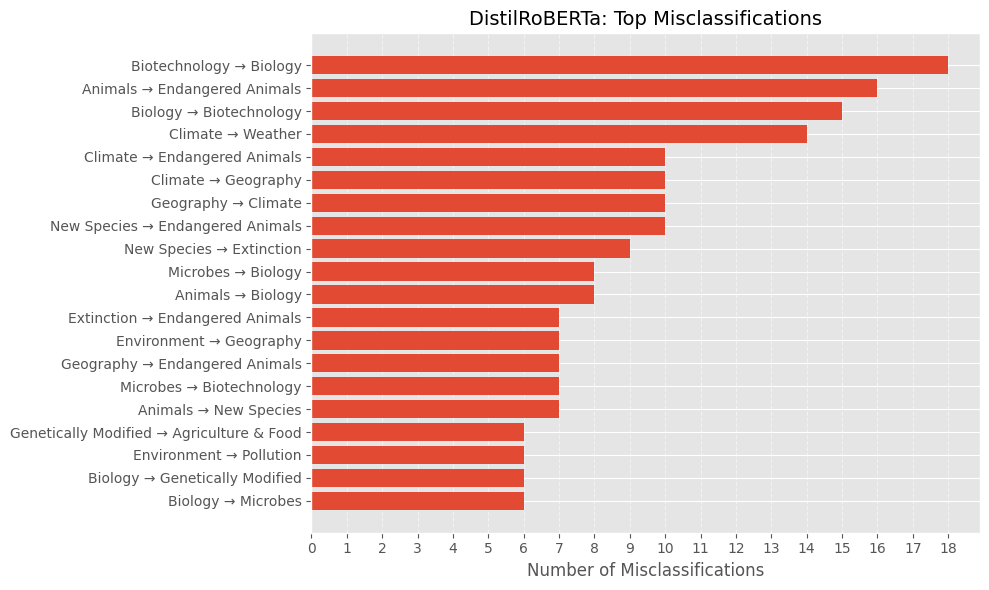

In [ ]:
import matplotlib.pyplot as plt

plt.style.use("ggplot")

def plot_top_errors(top_errors, title):
    plt.figure(figsize=(10, 6))
    
    plt.barh(
        top_errors["True"] + " → " + top_errors["Predicted"],
        top_errors["Count"]
    )
    
    plt.title(title, fontsize=14)
    plt.xlabel("Number of Misclassifications")
    
    # integer ticks
    max_val = int(top_errors["Count"].max())
    plt.xticks(range(0, max_val + 1, max(1, max_val // 10)))
    
    plt.grid(True, axis="x", linestyle="--", alpha=0.5)
    
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

plot_top_errors(top_errors, "DistilRoBERTa: Top Misclassifications")

In [ ]:
# Hardest classes overall

error_df.groupby("True")["Count"].sum().sort_values(ascending=False).head(10)

True
Climate               50
Biology               47
Animals               46
Environment           35
Geography             35
Biotechnology         30
Microbes              26
Endangered Animals    26
New Species           22
Agriculture & Food    21
Name: Count, dtype: int64

In [ ]:
# Over-predicted classes

error_df.groupby("Predicted")["Count"].sum().sort_values(ascending=False).head(10)

Predicted
Endangered Animals      62
Biology                 41
Weather                 33
Extinction              29
Geography               28
New Species             28
Biotechnology           25
Agriculture & Food      24
Animals                 23
Genetically Modified    23
Name: Count, dtype: int64